In [1]:
from huggingface_hub import hf_hub_download
import numpy as np

repo_id = "alrazz-n/bge-m3_spamham_best_model"

dev_logits_path = hf_hub_download(
    repo_id=repo_id,
    filename="dev_logits.npy",
)

dev_labels_path = hf_hub_download(
    repo_id=repo_id,
    filename="dev_labels.npy",
)

logits = np.load(dev_logits_path)
labels = np.load(dev_labels_path)

print(logits.shape)
print(labels.shape)

c:\Users\alrazz\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\alrazz\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\alrazz\.cache\huggingface\hub\models--alrazz-n--bge-m3_spamham_best_model. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as 

(614, 2)
(614,)


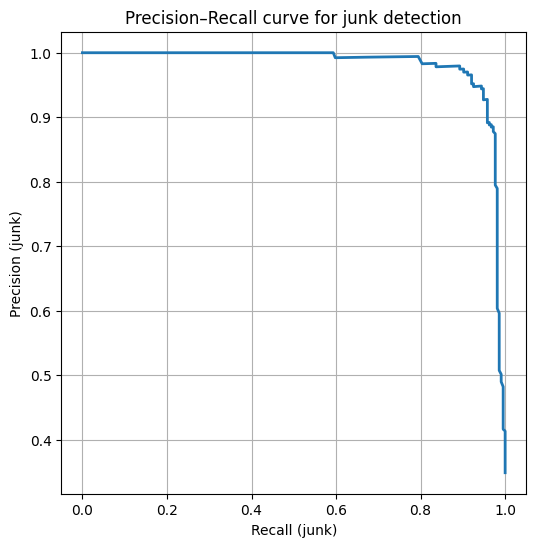

In [2]:
from scipy.special import softmax
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Probability of junk (class 0)
p0 = softmax(logits, axis=1)[:, 0]

precision, recall, thresholds = precision_recall_curve(
    labels == 0,   # treat junk as the positive class
    p0
)

plt.figure(figsize=(6,6))
plt.plot(recall, precision, lw=2)
plt.xlabel("Recall (junk)")
plt.ylabel("Precision (junk)")
plt.title("Precision–Recall curve for junk detection")
plt.grid(True)
plt.show()

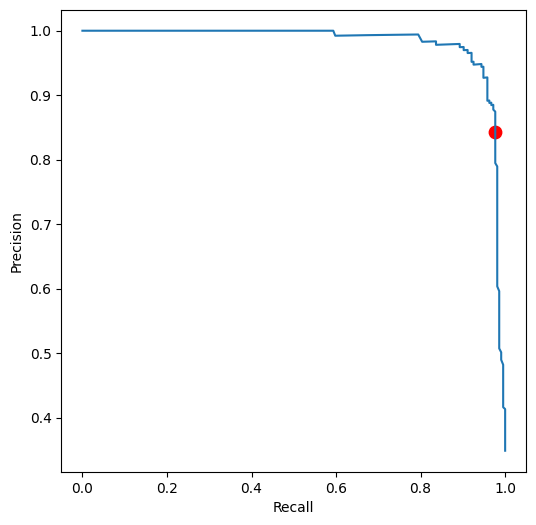

In [ ]:
# with the threshold found

threshold = 0.004

idx = np.argmin(np.abs(thresholds - threshold))

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.scatter(recall[idx], precision[idx], color="red", s=80)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

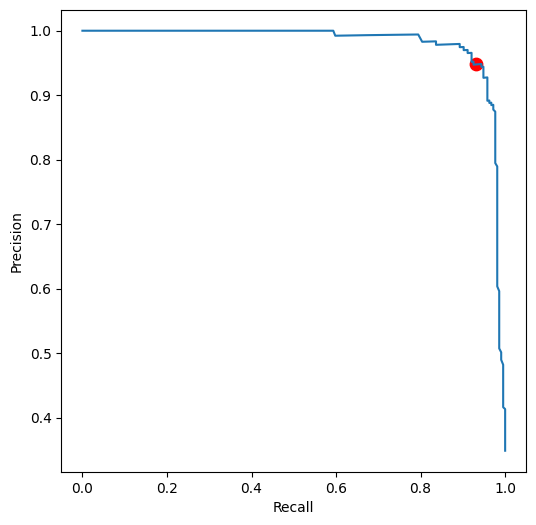

In [ ]:
# with the base threshold

threshold = 0.5

idx = np.argmin(np.abs(thresholds - threshold))

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.scatter(recall[idx], precision[idx], color="red", s=80)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

In [10]:
for t in [0.5,0.4, 0.3, 0.2,0.1,0.05,0.02,0.01,0.005,0.004,0.002]:
    pred = (p0 >= t).astype(int)

    # convert back to your labels
    pred = np.where(pred==1,0,1)

    from sklearn.metrics import precision_score, recall_score

    print(
        t,
        precision_score(labels,pred,pos_label=0),
        recall_score(labels,pred,pos_label=0)
    )

0.5 0.9476190476190476 0.9299065420560748
0.4 0.9478672985781991 0.9345794392523364
0.3 0.9483568075117371 0.9439252336448598
0.2 0.9269406392694064 0.9485981308411215
0.1 0.9111111111111111 0.9579439252336449
0.05 0.9111111111111111 0.9579439252336449
0.02 0.8884120171673819 0.9672897196261683
0.01 0.8708333333333333 0.9766355140186916
0.005 0.8565573770491803 0.9766355140186916
0.004 0.842741935483871 0.9766355140186916
0.002 0.5828729281767956 0.985981308411215


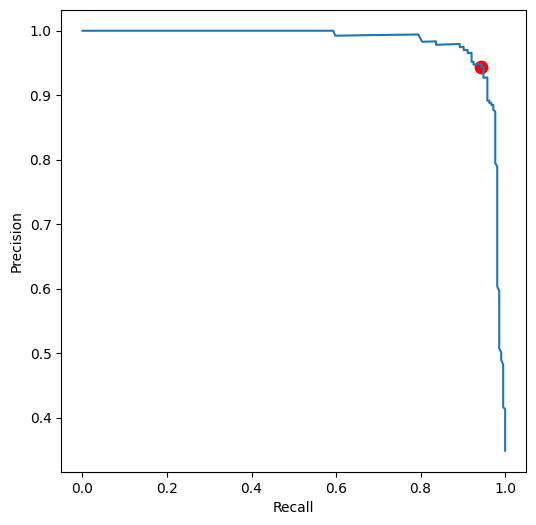

In [11]:
# with the base threshold

threshold = 0.3

idx = np.argmin(np.abs(thresholds - threshold))

plt.figure(figsize=(6,6))
plt.plot(recall, precision)
plt.scatter(recall[idx], precision[idx], color="red", s=80)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()

0.3 seems to be the best as
both Precision and Recall are good.

# Evaluating 0.3 threshold on the test set

In [13]:
test_logits_path = hf_hub_download(
    repo_id=repo_id,
    filename="test_logits.npy",
)

test_labels_path = hf_hub_download(
    repo_id=repo_id,
    filename="test_labels.npy",
)

In [14]:
test_logits = np.load(dev_logits_path)
test_labels = np.load(dev_labels_path)

print(test_logits.shape)
print(test_labels.shape)

(614, 2)
(614,)


In [15]:
import numpy as np
from scipy.special import softmax
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)

threshold = 0.3


# Probability of class 0 (junk)
p0 = softmax(test_logits, axis=1)[:, 0]

# Apply threshold
y_pred = np.where(p0 >= threshold, 0, 1)

print("Confusion matrix:")
print(confusion_matrix(test_labels, y_pred))

print("\nClassification report:")
print(classification_report(test_labels, y_pred, digits=4))

print("\nSummary:")
print(f"Precision (junk): {precision_score(test_labels, y_pred, pos_label=0):.4f}")
print(f"Recall (junk):    {recall_score(test_labels, y_pred, pos_label=0):.4f}")
print(f"Recall (good):    {recall_score(test_labels, y_pred, pos_label=1):.4f}")

Confusion matrix:
[[202  12]
 [ 11 389]]

Classification report:
              precision    recall  f1-score   support

           0     0.9484    0.9439    0.9461       214
           1     0.9701    0.9725    0.9713       400

    accuracy                         0.9625       614
   macro avg     0.9592    0.9582    0.9587       614
weighted avg     0.9625    0.9625    0.9625       614


Summary:
Precision (junk): 0.9484
Recall (junk):    0.9439
Recall (good):    0.9725


In [16]:
thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

for t in thresholds:
    y_pred = np.where(p0 >= t, 0, 1)

    print(f"\nThreshold = {t}")
    print(f"Precision junk: {precision_score(test_labels, y_pred, pos_label=0):.4f}")
    print(f"Recall junk:    {recall_score(test_labels, y_pred, pos_label=0):.4f}")
    print(f"Recall good:    {recall_score(test_labels, y_pred, pos_label=1):.4f}")


Threshold = 0.5
Precision junk: 0.9476
Recall junk:    0.9299
Recall good:    0.9725

Threshold = 0.4
Precision junk: 0.9479
Recall junk:    0.9346
Recall good:    0.9725

Threshold = 0.3
Precision junk: 0.9484
Recall junk:    0.9439
Recall good:    0.9725

Threshold = 0.2
Precision junk: 0.9269
Recall junk:    0.9486
Recall good:    0.9600

Threshold = 0.1
Precision junk: 0.9111
Recall junk:    0.9579
Recall good:    0.9500
